# 03 - Exploratory Data Analysis

## Online Retail Sales & Customer Analysis

This notebook explores the cleaned Online Retail transaction data to identify patterns in sales performance, products, customers, and geography.

The analysis builds on the data-understanding and cleaning stages. Rather than examining variables in isolation, the exploratory analysis focuses on questions that can provide meaningful insights into the business and guide subsequent customer-level analysis.

The main objectives are to:

* understand overall sales and transaction patterns;
* examine sales performance over time;
* identify important products and product-level patterns;
* explore geographic differences in sales;
* examine customer purchasing activity;
* identify patterns and questions that should be investigated in later analysis.

## 1. Load the Cleaned Dataset

The exploratory analysis is performed on the cleaned dataset produced in the data-cleaning stage.

The cleaning process removed exact duplicate records, standardized the `CustomerID` data type, and retained unusual transaction values where their meaning could not be determined reliably from the data alone.

Loading the cleaned dataset ensures that the exploratory analysis uses a consistent version of the data without repeating the cleaning process.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# Load Data

df = pd.read_csv(
    "../data/processed/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

In [27]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [28]:
df["InvoiceDate"].dt.month

0         12
1         12
2         12
3         12
4         12
          ..
536636    12
536637    12
536638    12
536639    12
536640    12
Name: InvoiceDate, Length: 536641, dtype: int32

In [29]:
df["InvoiceDate"].dt.year

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
536636    2011
536637    2011
536638    2011
536639    2011
536640    2011
Name: InvoiceDate, Length: 536641, dtype: int32

In [4]:
df.shape

(536641, 9)

In [23]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
dtype: object

In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [ ]:
df.head()

### 1.1 Restore CustomerID Data Type

When the cleaned dataset is saved as CSV and loaded again, Pandas may infer `CustomerID` as a floating-point column because the column contains missing values.

Since `CustomerID` is an identifier rather than a numerical measurement, it is converted back to Pandas' nullable `Int64` type for consistency with the cleaned dataset.

In [8]:
df["CustomerID"] = df["CustomerID"].astype("Int64")

In [9]:
df["CustomerID"].dtype

Int64Dtype()

## 2. Overall Business Overview

Before examining individual products, customers, or countries, it is useful to establish a baseline view of the dataset.

This section summarizes the overall scale of the transactions and the period covered by the data. The purpose is to understand the size and scope of the business represented in the dataset before investigating more detailed patterns.

The analysis will examine:

* total net revenue;
* total transaction lines;
* total invoices;
* total units recorded;
* the time period covered by the dataset.

### 2.1 Data Period

The transaction data covers the period from **1 December 2010** to **9 December 2011**.

Understanding the time range is important for interpreting sales trends and identifying possible seasonal patterns. Since the dataset spans approximately one year, monthly and time-based comparisons can provide useful insight into how sales activity changes throughout the observed period.


In [24]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [25]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

### 2.2 Overall Business Activity

The cleaned dataset contains **536,641 transaction lines** across **25,900 unique invoices**. The total recorded quantity is **5,162,502 units**, and the resulting net revenue is approximately **£9.73 million**.

These figures provide a baseline for the scale of the business represented in the dataset. The transaction-line count is substantially higher than the invoice count because a single invoice can contain multiple transaction lines.

The revenue and quantity totals include negative transactions, which are retained because they may represent returns, cancellations, or other negative adjustments. Therefore, the revenue reported here represents **net recorded revenue** rather than gross sales before such transactions.

In [30]:
df["Revenue"].sum()

np.float64(9726006.954)

In [31]:
len(df)

536641

In [32]:
df["InvoiceNo"].nunique()

25900

In [33]:
df["Quantity"].sum()

np.int64(5162502)

### 2.3 Dataset Entities

The dataset contains **4,372 identified customers**, **4,070 unique products**, and transactions from **38 countries**.

The customer count represents only transactions with an identified `CustomerID`. Missing customer identifiers are not counted as customers because they cannot be reliably attributed to a specific customer.

These figures provide an overview of the main entities represented in the dataset and establish the baseline for the more detailed product, geographic, and customer analyses that follow.

In [34]:
df["CustomerID"].nunique()

4372

In [35]:
df["StockCode"].nunique()

4070

In [36]:
df["Country"].nunique()

38

## 3. Sales Over Time

After establishing the overall scale of the dataset, the next step is to examine how sales activity changes over time.

Aggregating transactions by month allows us to identify overall trends, periods of increased or decreased activity, and potential seasonal patterns. This provides a clearer view of the business than examining individual transaction timestamps.

The initial focus will be on monthly revenue, followed by other measures of sales activity where useful.

In [39]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [43]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

In [44]:
monthly_revenue

Month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

In [45]:
len(monthly_revenue)

13

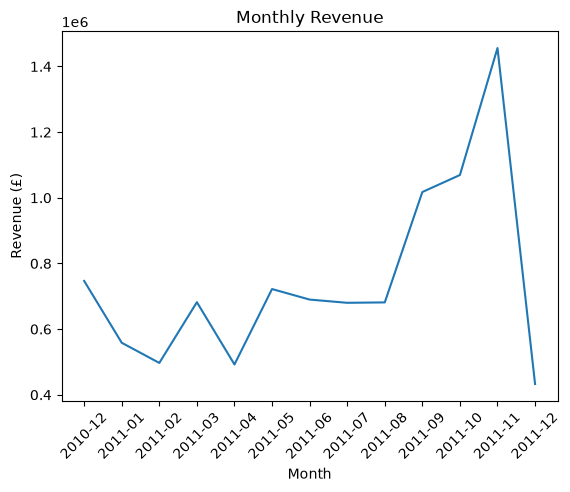

In [51]:
plt.plot(monthly_revenue.index.astype(str), monthly_revenue)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.show()

In [63]:
monthly_invoices = df.groupby("Month")["InvoiceNo"].nunique()

In [64]:
monthly_invoices

Month
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1737
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: InvoiceNo, dtype: int64

In [60]:
monthly_units = df.groupby("Month")["Quantity"].sum()

In [61]:
monthly_units

Month
2010-12    341038
2011-01    308281
2011-02    277374
2011-03    351165
2011-04    288237
2011-05    379652
2011-06    340945
2011-07    389051
2011-08    405450
2011-09    548669
2011-10    569749
2011-11    737182
2011-12    225709
Freq: M, Name: Quantity, dtype: int64

In [68]:
invoice_revenue = df.groupby(["Month", "InvoiceNo"])["Revenue"].sum()

In [69]:
invoice_revenue

Month    InvoiceNo
2010-12  536365          139.12
         536366           22.20
         536367          278.73
         536368           70.05
         536369           17.85
                        ...    
2011-12  C581484     -168469.60
         C581490         -32.53
         C581499        -224.69
         C581568         -54.75
         C581569          -7.50
Name: Revenue, Length: 25900, dtype: float64

In [72]:
monthly_avg_revenue_per_invoice = invoice_revenue.groupby("Month").mean()

In [73]:
monthly_avg_revenue_per_invoice

Month
2010-12    368.752400
2011-01    378.352683
2011-02    356.802879
2011-03    343.930398
2011-04    282.321010
2011-05    333.993571
2011-06    342.931029
2011-07    352.961594
2011-08    392.277755
2011-09    437.299820
2011-10    405.524547
2011-11    420.608261
2011-12    426.306463
Freq: M, Name: Revenue, dtype: float64

### 3.1 Findings

Monthly revenue shows a relatively weaker sales period during the beginning of the year, followed by more stable activity from approximately May to August. Revenue then increases substantially from September through November, with November recording the highest monthly revenue in the dataset.

The increase in revenue during September–November is accompanied by increases in both the number of invoices and the number of units recorded. Average revenue per invoice also remains relatively high during this period, but does not increase as sharply as total revenue. This suggests that the increase in total revenue is primarily associated with higher sales activity and volume, rather than a large increase in revenue generated by each individual invoice.

December should be interpreted cautiously because the dataset only contains transactions through **9 December 2011**, making it a partial month rather than a complete comparison with the preceding months.
